## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import pynance as pn
import talib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.data_cleaner import clean_stock_data
from src.technical_indicators import calculate_macd, calculate_moving_averages, calculate_rsi, generate_signal_summary
from src.financial_metrics import calculate_returns, calculate_volatility, calculate_sharpe_ratio, calculate_max_drawdown

## Load and Prepare Data

In [ ]:
df = load_data('../data/raw/AAPL.csv')

✅ Loaded: AAPL.csv
   Shape: (3774, 6) rows × 6 columns
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


## Clean data

In [6]:
df = clean_stock_data(df)


DATA CLEANING
--------------------------------------------------
✅ Date column converted to datetime
✅ Numeric columns converted
✅ Sorted by date
✅ No missing values found
✅ No duplicate dates
✅ High >= Low for all rows
✅ All rows have positive volume

Cleaned data: 3774 rows
   Date range: 2009-01-02 to 2023-12-29
   Close price range: $2.35 - $196.26


## Technical Indicators with TA-Lib

### MOVING AVERAGES

In [7]:
df = calculate_moving_averages(df)


📊 Moving Averages (windows: [5, 10, 20, 50, 200])
   ✅ SMA_5 and EMA_5 calculated
   ✅ SMA_10 and EMA_10 calculated
   ✅ SMA_20 and EMA_20 calculated
   ✅ SMA_50 and EMA_50 calculated
   ✅ SMA_200 and EMA_200 calculated

📊 Current Moving Averages (as of 2023-12-29):
--------------------------------------------------
   Close Price: $190.73
   SMA_5: $191.37  |  EMA_5: $191.57
   SMA_10: $192.76  |  EMA_10: $192.09
   SMA_20: $192.49  |  EMA_20: $191.43
   SMA_50: $184.81  |  EMA_50: $187.11
   SMA_200: $177.45  |  EMA_200: $176.11

📊 Price vs MA Signals:
   Price BELOW SMA_5 → Bearish signal
   Price BELOW SMA_10 → Bearish signal
   Price BELOW SMA_20 → Bearish signal
   Price ABOVE SMA_50 → Bullish signal
   Price ABOVE SMA_200 → Bullish signal


### RELATIVE STRENGTH INDEX (RSI)

In [8]:
df, rsi_summary = calculate_rsi(df)


📊 RSI (period=14)
   ✅ RSI calculated
   Current RSI: 51.12 → NEUTRAL (between 30 and 70)
   Historical: 574 overbought, 68 oversold days


### MACD (Moving Average Convergence Divergence)

In [9]:
df, macd_summary = calculate_macd(df)


📊 MACD (fast=12, slow=26, signal=9)
   ✅ MACD calculated
   MACD Line: 1.5595 | Signal: 2.4246 | Histogram: -0.8651
   Momentum: Bearish | Histogram: Decreasing


### Summary findings

In [10]:
generate_signal_summary(df)


TECHNICAL SIGNALS SUMMARY
Indicator  Signal
   SMA_20 Bearish
   SMA_50 Bullish
      RSI Neutral
     MACD Bearish


,Indicator,Signal
0,SMA_20,Bearish
1,SMA_50,Bullish
2,RSI,Neutral
3,MACD,Bearish


## PyNance for Financial Metrics

### CUMULATIVE RETURNS

In [12]:
df, cum_return = calculate_returns(df)


📊 Return Calculations
   Daily returns calculated
   Cumulative return: 6907.74%


### VOLATILITY (RISK)

In [13]:
df, vol_metrics = calculate_volatility(df)


📊 Volatility Metrics
   Daily volatility: 0.0180
   Annualized volatility: 28.59%


### SHARPE RATIO

In [14]:
sharpe = calculate_sharpe_ratio(df)


📊 Sharpe Ratio
   Annual return: 32.49%
   Risk-free rate: 2.0%
   Sharpe Ratio: 1.0663
   → Good risk-adjusted returns


### MAXIMUM DRAWDOWN

In [15]:
df, max_dd = calculate_max_drawdown(df)


📊 Maximum Drawdown
   Max Drawdown: -43.80%


### VISUALIZATION

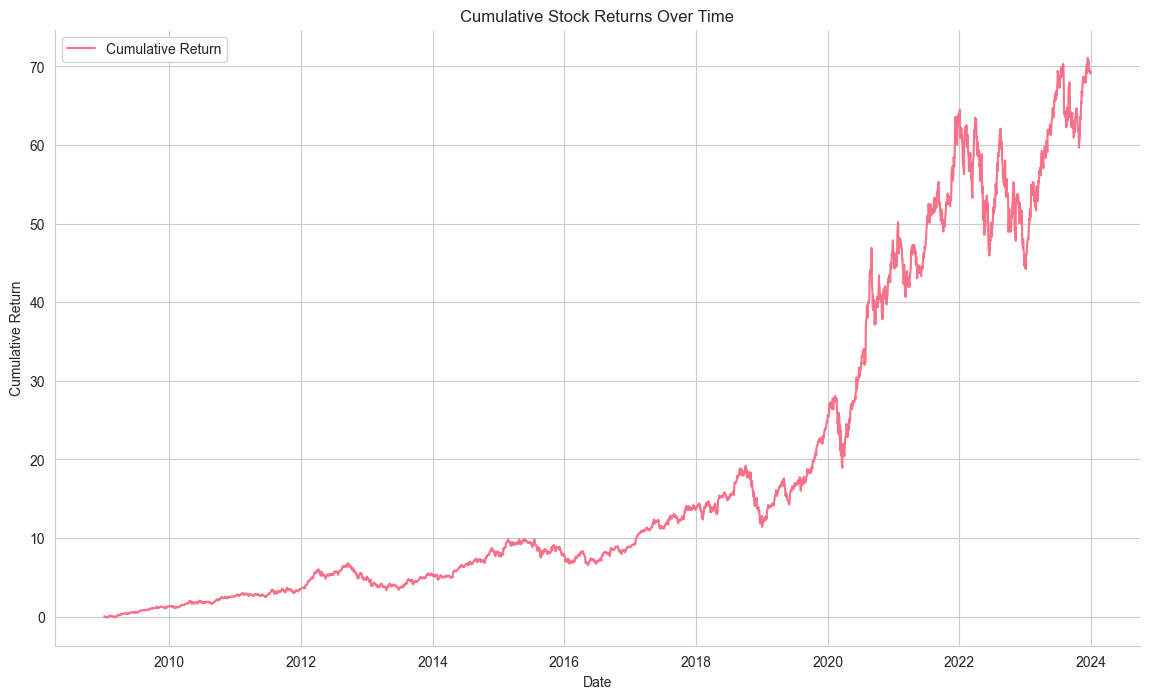

In [16]:
# Create figure
plt.figure(figsize=(14, 8))

# Plot cumulative return
plt.plot(df['Date'], df['Cumulative_Return'],
         label='Cumulative Return')

plt.title('Cumulative Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

plt.show()

## CREATE VISUALIZATION

### Price with Moving Averages

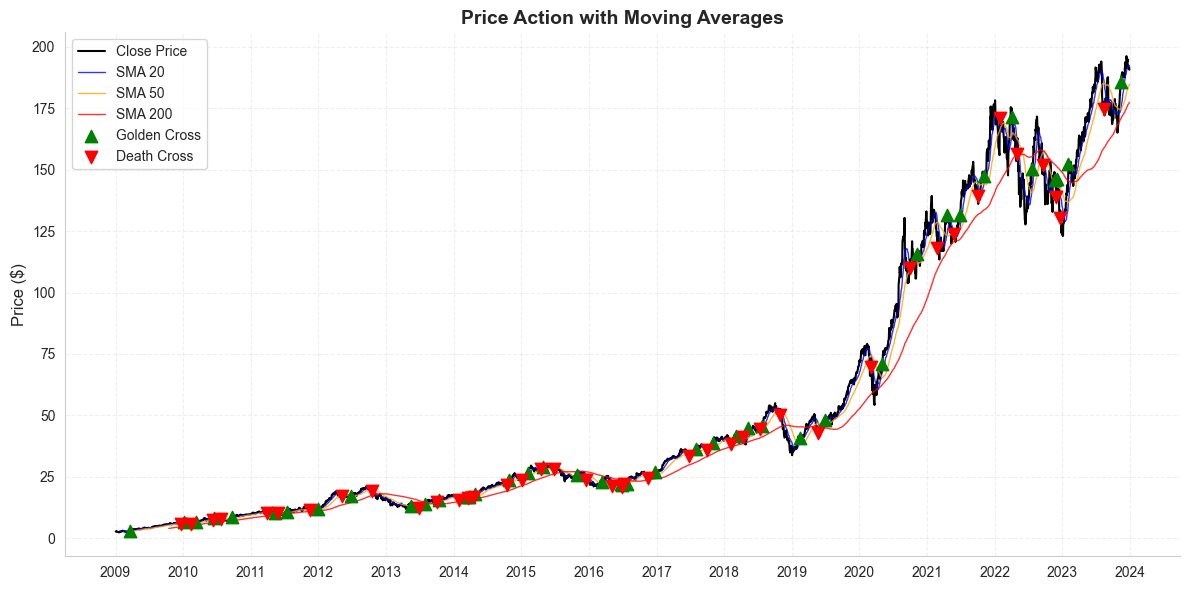

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Plot 1: Price with Moving Averages
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1, alpha=0.8)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1, alpha=0.8)

if 'SMA_200' in df.columns:
    ax1.plot(df['Date'], df['SMA_200'], label='SMA 200', color='red', linewidth=1, alpha=0.8)

# Highlight crossovers
if len(df) > 1:
    golden_cross = (df['SMA_20'] > df['SMA_50']) & (df['SMA_20'].shift(1) <= df['SMA_50'].shift(1))
    death_cross = (df['SMA_20'] < df['SMA_50']) & (df['SMA_20'].shift(1) >= df['SMA_50'].shift(1))
    
    ax1.scatter(df['Date'][golden_cross], df['Close'][golden_cross], 
                color='green', marker='^', s=80, zorder=5, label='Golden Cross')
    ax1.scatter(df['Date'][death_cross], df['Close'][death_cross], 
                color='red', marker='v', s=80, zorder=5, label='Death Cross')

ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Price Action with Moving Averages', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### RSI plot

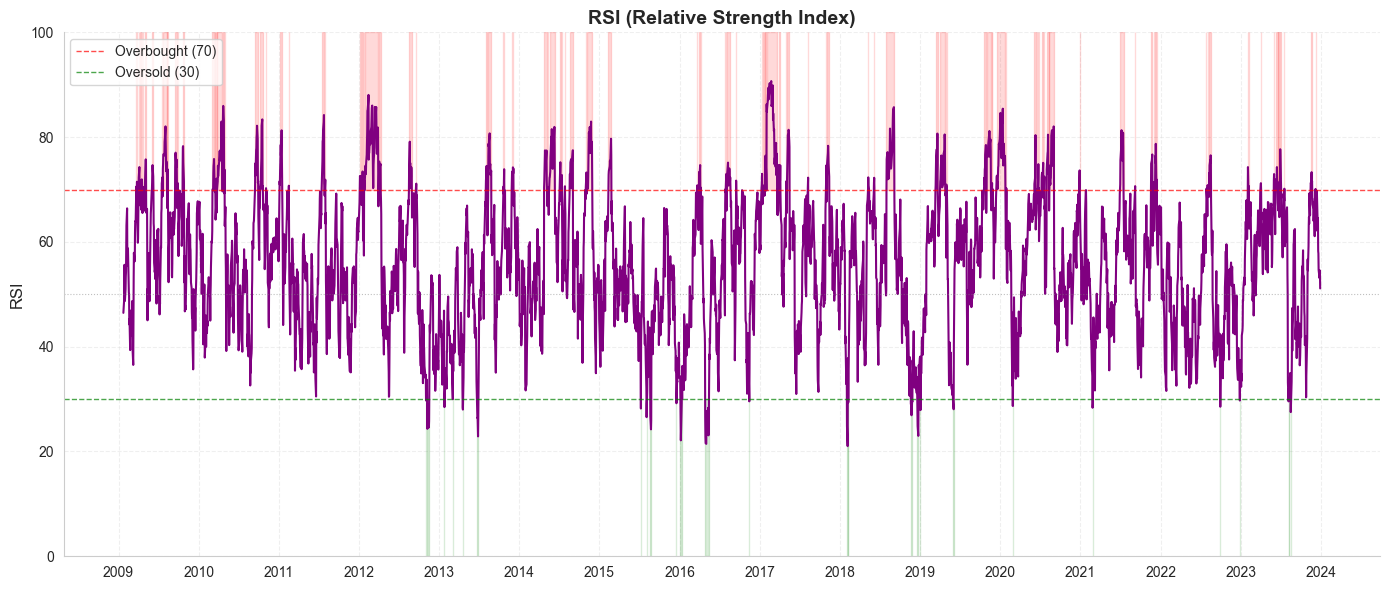

In [18]:
# Plot 2: RSI
fig2, ax2 = plt.subplots(figsize=(14, 6))

ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, linewidth=1, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

# Shade overbought/oversold regions
ax2.fill_between(df['Date'], 70, 100, where=(df['RSI'] >= 70), color='red', alpha=0.15)
ax2.fill_between(df['Date'], 0, 30, where=(df['RSI'] <= 30), color='green', alpha=0.15)

ax2.set_ylabel('RSI', fontsize=12)
ax2.set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### MACD plot

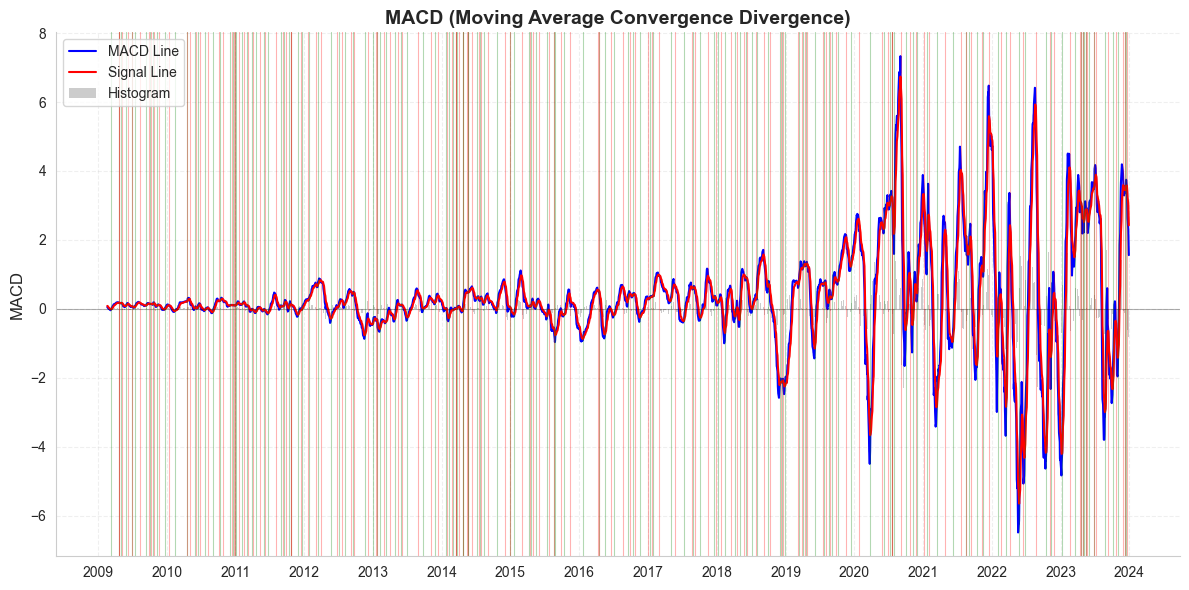

In [19]:
# Plot 3: MACD
fig3, ax3 = plt.subplots(figsize=(12, 6))

ax3.plot(df['Date'], df['MACD'], label='MACD Line', color='blue', linewidth=1.5)
ax3.plot(df['Date'], df['MACD_signal'], label='Signal Line', color='red', linewidth=1.5)
ax3.bar(df['Date'], df['MACD_histogram'], label='Histogram', 
        color='gray', alpha=0.4, width=0.8, edgecolor='none')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)

# Highlight MACD crossovers
if len(df) > 1:
    macd_bullish = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
    macd_bearish = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))
    
    for idx in macd_bullish[macd_bullish].index:
        ax3.axvline(x=df['Date'].iloc[idx], color='green', alpha=0.3, linewidth=0.8)
    for idx in macd_bearish[macd_bearish].index:
        ax3.axvline(x=df['Date'].iloc[idx], color='red', alpha=0.3, linewidth=0.8)

ax3.set_ylabel('MACD', fontsize=12)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Volume with Signals

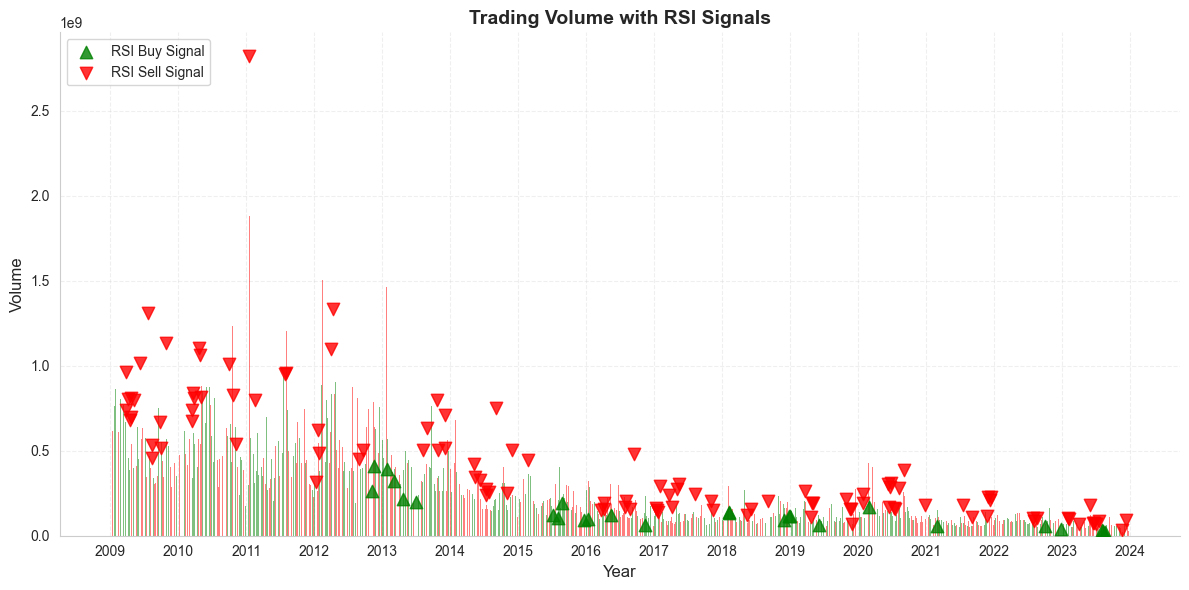

In [20]:
# Plot 4: Volume with Buy/Sell Signals
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Color volume bars: green for up days, red for down days
colors = ['green' if df['Close'].iloc[i] >= df['Close'].iloc[i-1] else 'red' 
          for i in range(len(df))]
colors[0] = 'gray'

ax4.bar(df['Date'], df['Volume'], color=colors, alpha=0.5, width=0.8, edgecolor='none')

# RSI signals
rsi_buy_signal = (df['RSI'] > 30) & (df['RSI'].shift(1) <= 30)
rsi_sell_signal = (df['RSI'] < 70) & (df['RSI'].shift(1) >= 70)

ax4.scatter(df['Date'][rsi_buy_signal], df['Volume'][rsi_buy_signal] * 0.5,
            color='green', marker='^', s=80, zorder=5, label='RSI Buy Signal', alpha=0.8)
ax4.scatter(df['Date'][rsi_sell_signal], df['Volume'][rsi_sell_signal] * 1.5,
            color='red', marker='v', s=80, zorder=5, label='RSI Sell Signal', alpha=0.8)

ax4.set_ylabel('Volume', fontsize=12)
ax4.set_xlabel('Year', fontsize=12)
ax4.set_title('Trading Volume with RSI Signals', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.xaxis.set_major_locator(mdates.YearLocator())
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### RELATIONSHIP VISUALIZATION: How Indicators Relate to Price Action

C:\Users\hp\AppData\Local\Temp\ipykernel_18256\843473984.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)


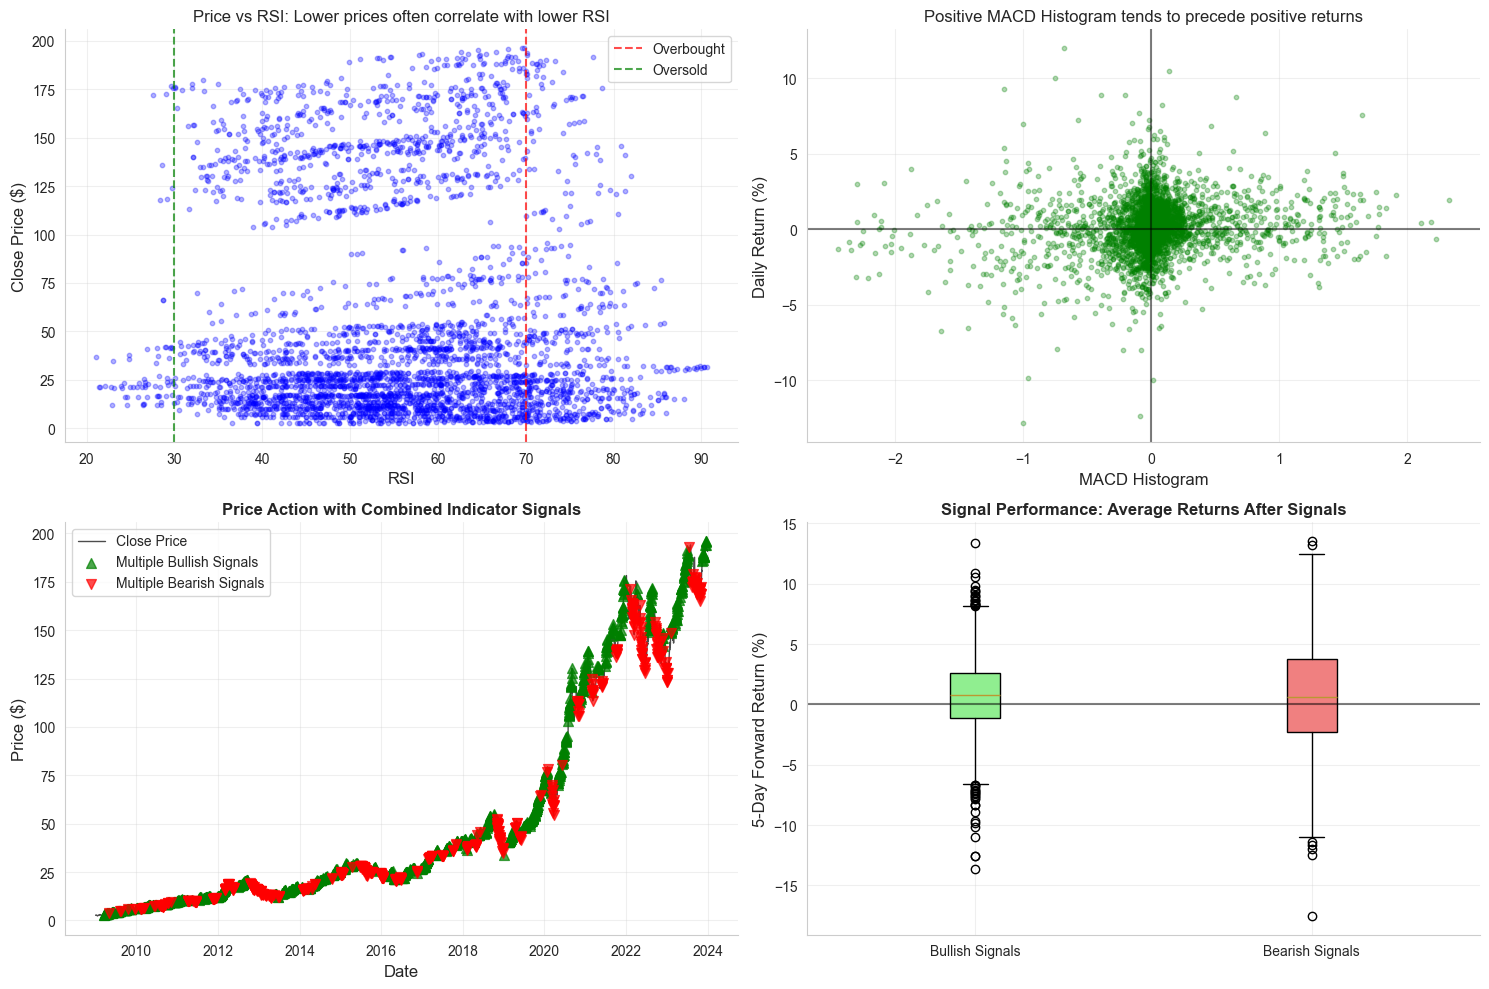

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 3a. RSI vs Price (scatter)
ax = axes[0, 0]
ax.scatter(df['RSI'], df['Close'], alpha=0.3, s=10, c='blue')
ax.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.7, label='Oversold')
ax.set_xlabel('RSI', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.set_title('Price vs RSI: Lower prices often correlate with lower RSI', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 3b. MACD Histogram vs Price Returns
ax = axes[0, 1]
ax.scatter(df['MACD_histogram'], df['Daily_Return'] * 100, alpha=0.3, s=10, c='green')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('MACD Histogram', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_title('Positive MACD Histogram tends to precede positive returns', fontsize=12)
ax.grid(True, alpha=0.3)

# 3c. Price with indicator signals highlighted
ax = axes[1, 0]
ax.plot(df['Date'], df['Close'], color='black', linewidth=1, alpha=0.7, label='Close Price')

# Highlight days with multiple bullish signals
bullish_signals = pd.Series(0, index=df.index)
bearish_signals = pd.Series(0, index=df.index)

# Combine signals (simplified scoring)
if 'RSI' in df.columns:
    bullish_signals += (df['RSI'] < 30).astype(int)
    bearish_signals += (df['RSI'] > 70).astype(int)

if 'MACD' in df.columns and 'MACD_signal' in df.columns:
    bullish_signals += (df['MACD'] > df['MACD_signal']).astype(int)
    bearish_signals += (df['MACD'] < df['MACD_signal']).astype(int)

if 'SMA_20' in df.columns and 'SMA_50' in df.columns:
    bullish_signals += (df['SMA_20'] > df['SMA_50']).astype(int)
    bearish_signals += (df['SMA_20'] < df['SMA_50']).astype(int)

# Mark high-signal days
strong_bullish = bullish_signals >= 2
strong_bearish = bearish_signals >= 2

ax.scatter(df['Date'][strong_bullish], df['Close'][strong_bullish], 
           color='green', marker='^', s=50, alpha=0.7, label='Multiple Bullish Signals', zorder=5)
ax.scatter(df['Date'][strong_bearish], df['Close'][strong_bearish], 
           color='red', marker='v', s=50, alpha=0.7, label='Multiple Bearish Signals', zorder=5)

ax.set_ylabel('Price ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Price Action with Combined Indicator Signals', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

# 3d. Signal Performance (Returns after signals)
ax = axes[1, 1]

# Calculate forward returns after signals
forward_returns = []
signal_types = []

for i in strong_bullish[strong_bullish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bullish')

for i in strong_bearish[strong_bearish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bearish')

if len(forward_returns) > 0:
    box_data = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bullish']
    box_data_bear = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bearish']
    
    bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.set_ylabel('5-Day Forward Return (%)', fontsize=12)
    ax.set_title('Signal Performance: Average Returns After Signals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### SUMMARY OF FINDINGS

In [34]:
print(f"""
📊 Moving Averages:
   - Golden Cross (Bullish) signals: {golden_cross.sum()}
   - Death Cross (Bearish) signals: {death_cross.sum()}

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: {rsi_buy_signal.sum()}
   - Overbought (RSI > 70) sell signals: {rsi_sell_signal.sum()}

📊 MACD Crossovers:
   - Bullish crossovers: {macd_bullish.sum()}
   - Bearish crossovers: {macd_bearish.sum()}

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: {strong_bullish.sum()}
   - Days with 2+ bearish signals: {strong_bearish.sum()}
""")

# Calculate average returns after signals
if len(forward_returns) > 0:
    bullish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bullish']) * 100
    bearish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bearish']) * 100
    print(f"   Avg 5-day return after bullish signals: {bullish_avg_return:.2f}%")
    print(f"   Avg 5-day return after bearish signals: {bearish_avg_return:.2f}%")


📊 Moving Averages:
   - Golden Cross (Bullish) signals: 39
   - Death Cross (Bearish) signals: 39

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: 22
   - Overbought (RSI > 70) sell signals: 82

📊 MACD Crossovers:
   - Bullish crossovers: 150
   - Bearish crossovers: 150

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: 1103
   - Days with 2+ bearish signals: 540

   Avg 5-day return after bullish signals: 0.34%
   Avg 5-day return after bearish signals: 1.06%
